In [1]:
# Install dependencies
!pip install -q torch torchvision
!pip install -q git+https://github.com/facebookresearch/detectron2.git


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 133.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 98.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 63.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 42.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 109.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 5.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [4]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!unzip -q "/content/drive/MyDrive/coco_v3.zip" -d /content/data/coco

In [5]:
!unzip -q "/content/drive/MyDrive/png.zip" -d /content/data/images

In [64]:
from detectron2.data import DatasetCatalog, MetadataCatalog

for name in ["chart_train", "chart_val", "chart_test"]:
    if name in DatasetCatalog:
        DatasetCatalog.remove(name)
    if name in MetadataCatalog:
        MetadataCatalog.remove(name)


In [65]:

from detectron2.data.datasets import register_coco_instances
from detectron2.data import MetadataCatalog

# Base path
data_path = "/content/data"

# Register COCO datasets
register_coco_instances("chart_train", {}, f"{data_path}/coco/train_coco_annotations_v4.json", f"{data_path}/images/png")
register_coco_instances("chart_val", {}, f"{data_path}/coco/val_coco_annotations_v4.json", f"{data_path}/images/png")
register_coco_instances("chart_test", {}, f"{data_path}/coco/test_coco_annotations_v4.json", f"{data_path}/images/png")

# Optional: define class labels (must match your COCO annotation IDs)
MetadataCatalog.get("chart_train").thing_classes = [
    'ChartTitle', 'PlotArea', 'LegendLabel', 'xAxisLabel', 'yAxisLabel',
    'PieLabel', 'v_bar', 'h_bar', 'line', 'yAxisTitle'
]



In [66]:
from detectron2.data import DatasetCatalog
print(len(DatasetCatalog.get("chart_train")))


[07/18 21:28:11 d2.data.datasets.coco]: Loading /content/data/coco/train_coco_annotations_v4.json takes 3.67 seconds.
WARNING [07/18 21:28:11 d2.data.datasets.coco]: 
Category ids in annotations are not in [1, #categories]! We'll apply a mapping for you.

[07/18 21:28:11 d2.data.datasets.coco]: Loaded 12821 images in COCO format from /content/data/coco/train_coco_annotations_v4.json
12821


In [67]:
from detectron2.config import get_cfg
from detectron2 import model_zoo
from detectron2.engine import DefaultTrainer
import os

# Setup config
cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file(
    "COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml"))

cfg.DATASETS.TRAIN = ("chart_train",)
cfg.DATASETS.TEST = ("chart_val",)
cfg.DATALOADER.NUM_WORKERS = 2

# Load pre-trained COCO weights
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url(
    "COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml")

cfg.SOLVER.IMS_PER_BATCH = 2
cfg.SOLVER.BASE_LR = 0.00025
cfg.SOLVER.MAX_ITER = 3000  # Adjust as needed
cfg.MODEL.ROI_HEADS.BATCH_SIZE_PER_IMAGE = 128
cfg.MODEL.ROI_HEADS.NUM_CLASSES = 10  # Your number of classes
cfg.TEST.EVAL_PERIOD = 500 # Evaluate every 500 iterations

cfg.OUTPUT_DIR = "/content/output_chart_rcnn/v2"
os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)

# Start training
trainer = DefaultTrainer(cfg)
trainer.resume_or_load(resume=False)
trainer.train()


[07/18 21:28:14 d2.engine.defaults]: Model:
GeneralizedRCNN(
  (backbone): FPN(
    (fpn_lateral2): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral3): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral4): Conv2d(1024, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral5): Conv2d(2048, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (top_block): LastLevelMaxPool()
    (bottom_up): ResNet(
      (stem): BasicStem(
        (conv1): Conv2d(
          3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
          (norm): FrozenBatchNorm2d(num_features=64, eps=1e-05)
        )
      )
      (res

roi_heads.box_predictor.bbox_pred.{bias, weight}
roi_heads.box_predictor.cls_score.{bias, weight}


[07/18 21:28:22 d2.engine.train_loop]: Starting training from iteration 0
[07/18 21:28:26 d2.utils.events]:  eta: 0:09:20  iter: 19  total_loss: 8.004  loss_cls: 2.309  loss_box_reg: 0.4496  loss_rpn_cls: 4.626  loss_rpn_loc: 0.4158    time: 0.1894  last_time: 0.2069  data_time: 0.0138  last_data_time: 0.0026   lr: 4.9953e-06  max_mem: 3947M
[07/18 21:28:30 d2.utils.events]:  eta: 0:09:28  iter: 39  total_loss: 5.848  loss_cls: 2.174  loss_box_reg: 0.697  loss_rpn_cls: 2.695  loss_rpn_loc: 0.385    time: 0.1902  last_time: 0.1587  data_time: 0.0042  last_data_time: 0.0040   lr: 9.9902e-06  max_mem: 3947M
[07/18 21:28:34 d2.utils.events]:  eta: 0:09:33  iter: 59  total_loss: 3.759  loss_cls: 1.976  loss_box_reg: 0.7229  loss_rpn_cls: 0.6713  loss_rpn_loc: 0.3794    time: 0.1925  last_time: 0.1624  data_time: 0.0040  last_data_time: 0.0024   lr: 1.4985e-05  max_mem: 4350M
[07/18 21:28:37 d2.utils.events]:  eta: 0:09:29  iter: 79  total_loss: 3.261  loss_cls: 1.705  loss_box_reg: 0.6688  

In [68]:
from detectron2.engine import DefaultPredictor
from detectron2.evaluation import COCOEvaluator, inference_on_dataset
from detectron2.data import build_detection_test_loader

# Load trained config
cfg.MODEL.WEIGHTS = os.path.join(cfg.OUTPUT_DIR, "model_final.pth")
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5  # Confidence threshold

# Initialize predictor (optional for visualization later)
predictor = DefaultPredictor(cfg)


[07/18 21:38:19 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from /content/output_chart_rcnn/v2/model_final.pth ...


In [69]:
# Create evaluator and test loader
evaluator_val = COCOEvaluator("chart_val", cfg, False, output_dir=cfg.OUTPUT_DIR)
val_loader = build_detection_test_loader(cfg, "chart_val")

# Run evaluation
print(" Evaluating on validation set...")
inference_on_dataset(predictor.model, val_loader, evaluator_val)


WARNING [07/18 21:38:24 d2.evaluation.coco_evaluation]: COCO Evaluator instantiated using config, this is deprecated behavior. Please pass in explicit arguments instead.
[07/18 21:38:26 d2.data.datasets.coco]: Loading /content/data/coco/val_coco_annotations_v4.json takes 1.52 seconds.
WARNING [07/18 21:38:26 d2.data.datasets.coco]: 
Category ids in annotations are not in [1, #categories]! We'll apply a mapping for you.

[07/18 21:38:26 d2.data.datasets.coco]: Loaded 2748 images in COCO format from /content/data/coco/val_coco_annotations_v4.json
[07/18 21:38:27 d2.data.dataset_mapper]: [DatasetMapper] Augmentations used in inference: [ResizeShortestEdge(short_edge_length=(800, 800), max_size=1333, sample_style='choice')]
[07/18 21:38:27 d2.data.common]: Serializing the dataset using: <class 'detectron2.data.common._TorchSerializedList'>
[07/18 21:38:27 d2.data.common]: Serializing 2748 elements to byte tensors and concatenating them all ...
[07/18 21:38:27 d2.data.common]: Serialized da

OrderedDict([('bbox',
              {'AP': 55.320048592775706,
               'AP50': 81.1051489607529,
               'AP75': 63.67588913018689,
               'APs': 43.49475598474562,
               'APm': 52.28734601323919,
               'APl': 45.20352996398768,
               'AP-ChartTitle': 43.24447632516911,
               'AP-PlotArea': 80.96672979760824,
               'AP-LegendLabel': 41.954399079635316,
               'AP-xAxisLabel': 68.97936057384577,
               'AP-yAxisLabel': 42.11817877350661,
               'AP-PieLabel': 52.01693821057655,
               'AP-v_bar': 64.95367490534846,
               'AP-h_bar': 61.770539423300576,
               'AP-line': 30.9695314940075,
               'AP-yAxisTitle': 66.22665734475882})])

In [70]:
# Reuse same config and model
evaluator_test = COCOEvaluator("chart_test", cfg, False, output_dir=cfg.OUTPUT_DIR)
test_loader = build_detection_test_loader(cfg, "chart_test")

# Run evaluation
print(" Evaluating on test set...")
inference_on_dataset(predictor.model, test_loader, evaluator_test)


WARNING [07/18 21:40:41 d2.evaluation.coco_evaluation]: COCO Evaluator instantiated using config, this is deprecated behavior. Please pass in explicit arguments instead.
[07/18 21:40:43 d2.data.datasets.coco]: Loading /content/data/coco/test_coco_annotations_v4.json takes 1.45 seconds.
WARNING [07/18 21:40:43 d2.data.datasets.coco]: 
Category ids in annotations are not in [1, #categories]! We'll apply a mapping for you.

[07/18 21:40:43 d2.data.datasets.coco]: Loaded 2748 images in COCO format from /content/data/coco/test_coco_annotations_v4.json
[07/18 21:40:44 d2.data.dataset_mapper]: [DatasetMapper] Augmentations used in inference: [ResizeShortestEdge(short_edge_length=(800, 800), max_size=1333, sample_style='choice')]
[07/18 21:40:44 d2.data.common]: Serializing the dataset using: <class 'detectron2.data.common._TorchSerializedList'>
[07/18 21:40:44 d2.data.common]: Serializing 2748 elements to byte tensors and concatenating them all ...
[07/18 21:40:44 d2.data.common]: Serialized 

OrderedDict([('bbox',
              {'AP': 55.09845202753083,
               'AP50': 80.96386671181855,
               'AP75': 63.359349134013534,
               'APs': 43.66174207115114,
               'APm': 52.01170916653191,
               'APl': 44.218888437267864,
               'AP-ChartTitle': 42.26069533515998,
               'AP-PlotArea': 80.7580145134513,
               'AP-LegendLabel': 42.677003172498,
               'AP-xAxisLabel': 68.75004264737504,
               'AP-yAxisLabel': 43.9227738385203,
               'AP-PieLabel': 46.4994212428706,
               'AP-v_bar': 67.45026581416896,
               'AP-h_bar': 58.353482935487456,
               'AP-line': 32.309546543067,
               'AP-yAxisTitle': 68.00327423270961})])

In [77]:
evaluator_val = COCOEvaluator("chart_val", cfg, False, output_dir="/content/eval_val")


WARNING [07/18 21:44:26 d2.evaluation.coco_evaluation]: COCO Evaluator instantiated using config, this is deprecated behavior. Please pass in explicit arguments instead.


In [72]:
import glob

print(glob.glob("/content/output_chart_rcnn/**/*.pth", recursive=True))


['/content/output_chart_rcnn/v4/model_final.pth', '/content/output_chart_rcnn/v4/instances_predictions.pth', '/content/output_chart_rcnn/v2/model_final.pth', '/content/output_chart_rcnn/v2/instances_predictions.pth']


In [79]:
from detectron2.engine import DefaultPredictor
from detectron2.config import get_cfg
from detectron2 import model_zoo
import os

# Setup config (same as training)
cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file("COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml"))
cfg.MODEL.ROI_HEADS.NUM_CLASSES = 10  # Your number of classes
cfg.MODEL.WEIGHTS = os.path.join("/content/output_chart_rcnn/v2", "model_final.pth")  # Trained weights
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5  # Only show predictions > 50% confidence
cfg.DATASETS.TEST = ("chart_test",)

predictor = DefaultPredictor(cfg)


[07/18 21:45:56 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from /content/output_chart_rcnn/v2/model_final.pth ...


In [80]:
from detectron2.data import MetadataCatalog, DatasetCatalog
from detectron2.utils.visualizer import Visualizer
import cv2
import random
from google.colab.patches import cv2_imshow

# Get test metadata
metadata = MetadataCatalog.get("chart_test")
dataset_dicts = DatasetCatalog.get("chart_test")


[07/18 21:46:13 d2.data.datasets.coco]: Loading /content/data/coco/test_coco_annotations_v4.json takes 1.29 seconds.
WARNING [07/18 21:46:13 d2.data.datasets.coco]: 
Category ids in annotations are not in [1, #categories]! We'll apply a mapping for you.

[07/18 21:46:13 d2.data.datasets.coco]: Loaded 2748 images in COCO format from /content/data/coco/test_coco_annotations_v4.json


 Image: two_col_4120.png


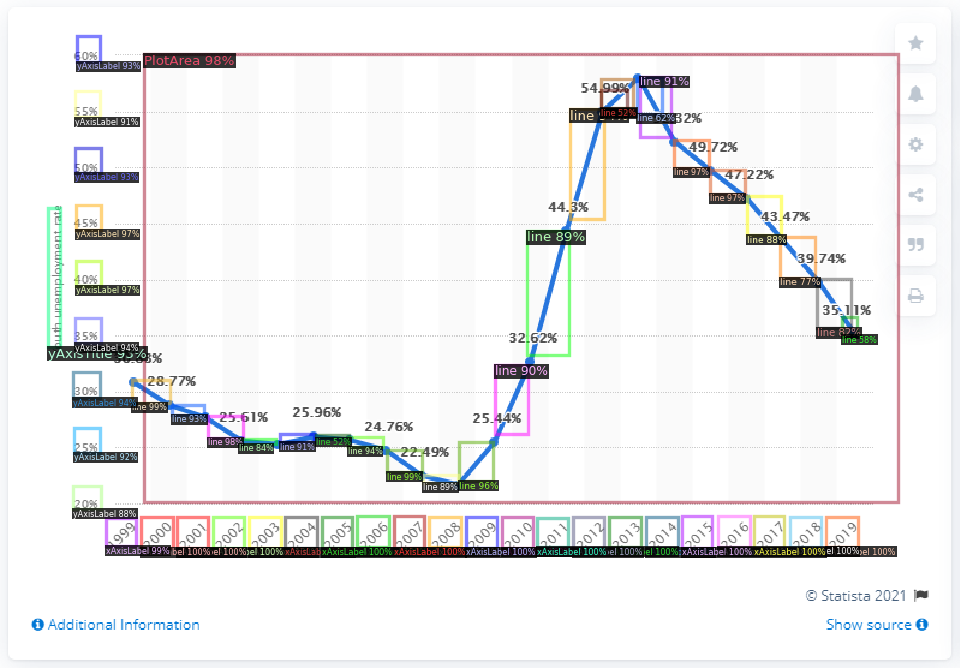

 Image: two_col_80846.png


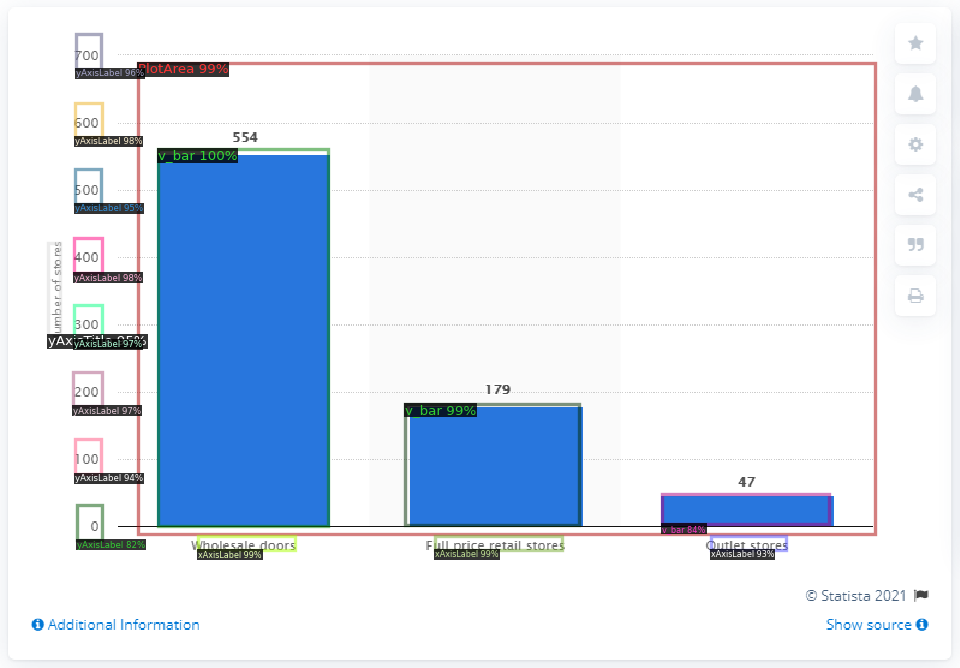

 Image: two_col_23912.png


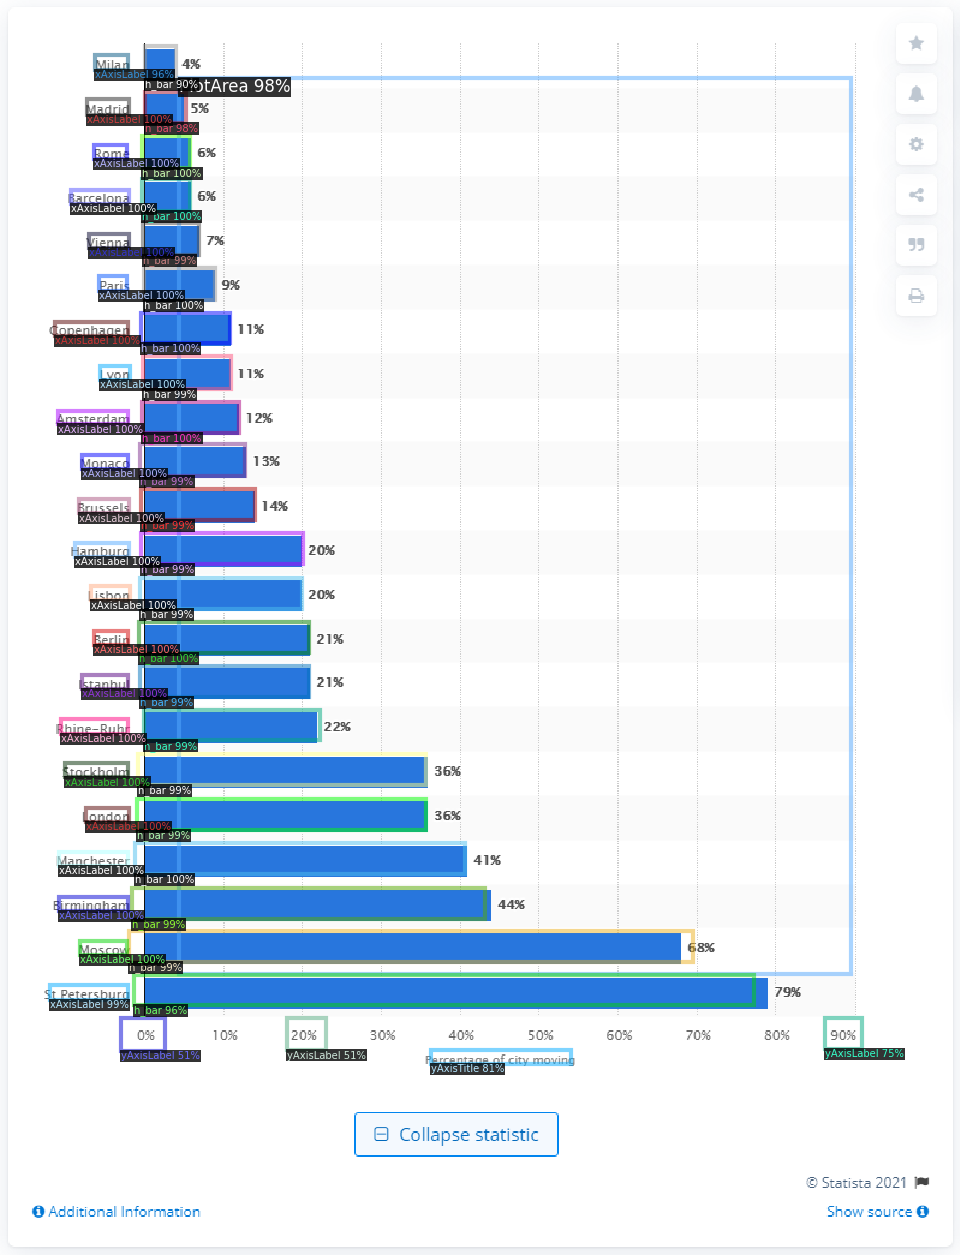

 Image: multi_col_20992.png


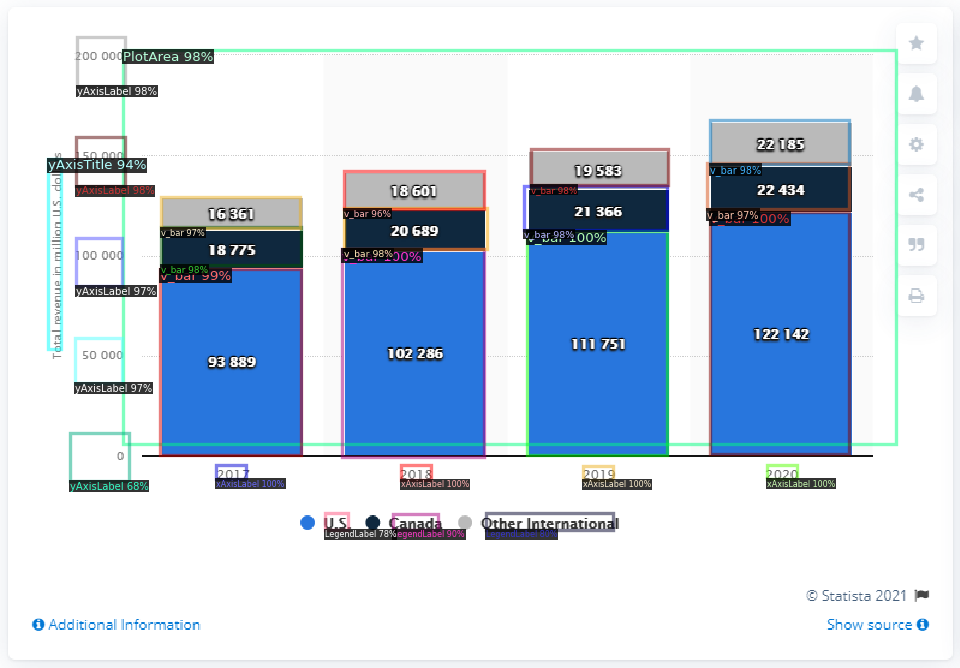

 Image: two_col_104595.png


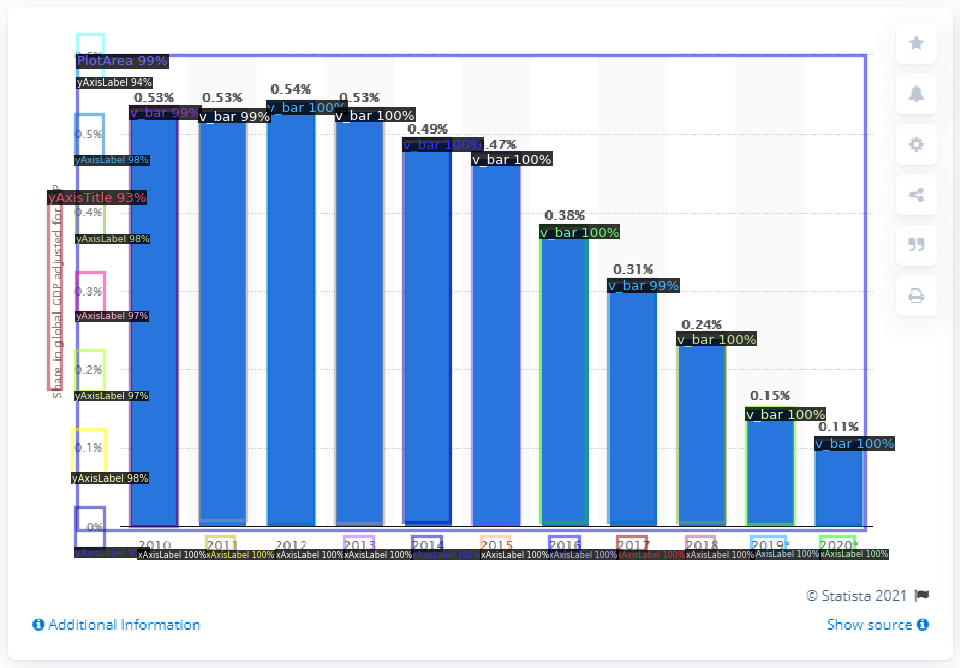

In [82]:
for d in random.sample(dataset_dicts, 5):  # Show 5 random test images
    img_path = d["file_name"]
    print(f" Image: {os.path.basename(img_path)}")  # Print just the file name

    img = cv2.imread(img_path)
    outputs = predictor(img)  # Run inference

    v = Visualizer(img[:, :, ::-1], metadata=metadata, scale=1.2)
    out = v.draw_instance_predictions(outputs["instances"].to("cpu"))

    cv2_imshow(out.get_image()[:, :, ::-1])
